In [1]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

import glob
from pathlib import Path

import scipy
import numpy as np
import pandas as pd

from aicsimageio import AICSImage, readers

from tqdm import tqdm

from matplotlib import pyplot as plt
import seaborn as sns

In [2]:
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = 'Arial'
plt.rcParams['svg.fonttype'] = 'none'

## load layout from file, and plot to check

In [3]:
layout1 = pd.read_csv("250407_mACmChPOLR2A_Inhibitors/METADATA/250407_mACmChPOLR2A_Inhibitors.csv")
layout2 = pd.read_csv("250411_mACmChPOLR2A_Inhibitors/METADATA/250411_mACmChPOLR2A_Inhibitors.csv")

## load quantification files from relevant directories, and assemble into data frames

In [4]:
quantification_directory_1 = Path("/Users/alexandergillis/Desktop/KATANA_PULL/250407_mACmChPOLR2A_Inhibitors/20250410_195120_719/QUANTIFICATION")
quantification_files_1 = glob.glob(str(quantification_directory_1 / "*.csv"))

quantification_directory_2 = Path("/Users/alexandergillis/Desktop/KATANA_PULL/250411_mACmChPOLR2A_Inhibitors/20250414_194232_089/QUANTIFICATION")
quantification_files_2 = glob.glob(str(quantification_directory_2 / "*.csv"))

In [5]:
len(quantification_files_1),len(quantification_files_2)

(799, 800)

In [6]:
Path(quantification_files_1[100]).stem, Path(quantification_files_1[100]).stem[4:7],Path(quantification_files_1[100]).stem[40:44]

('WellI17_Channel561,405,None,488_Seq0105_0002.ome', 'I17', '0002')

In [7]:
qdfs = list()


for f in tqdm(quantification_files_1):
    data = pd.read_csv(f)
    data['file'] = Path(f).stem
    qdfs.append(data)

quantifcation_percell_1 = pd.concat(qdfs, ignore_index=True)

files = quantifcation_percell_1['file'].tolist()


wellnames = [f[4:7] for f in files]
quantifcation_percell_1['well'] = wellnames

fovs = [f[39:43] for f in files]
quantifcation_percell_1['fov'] = fovs

Intensities1 = pd.DataFrame({
    "WELL" : quantifcation_percell_1['well'],
    "RFP_561_Intensity" : quantifcation_percell_1['Nuclei_intensity_mean_561'],
    "GFP_488_Intensity" : quantifcation_percell_1['Nuclei_intensity_mean_488'],
    "DAPI_Intensity" : quantifcation_percell_1['Nuclei_intensity_mean_405'],
    "NucleusArea" : quantifcation_percell_1['Nuclei_area']
})

Intensities1['EXPERIMENT'] = '250407_mACmChPOLR2A_Inhibitors'

100%|████████████████████████████████████████| 799/799 [00:07<00:00, 106.77it/s]


In [8]:
qdfs = list()


for f in tqdm(quantification_files_2):
    data = pd.read_csv(f)
    data['file'] = Path(f).stem
    qdfs.append(data)

quantifcation_percell_2 = pd.concat(qdfs, ignore_index=True)

files = quantifcation_percell_2['file'].tolist()


wellnames = [f[4:7] for f in files]
quantifcation_percell_2['well'] = wellnames

fovs = [f[39:43] for f in files]
quantifcation_percell_2['fov'] = fovs

Intensities2 = pd.DataFrame({
    "WELL" : quantifcation_percell_2['well'],
    "RFP_561_Intensity" : quantifcation_percell_2['Nuclei_intensity_mean_561'],
    "GFP_488_Intensity" : quantifcation_percell_2['Nuclei_intensity_mean_488'],
    "DAPI_Intensity" : quantifcation_percell_2['Nuclei_intensity_mean_405'],
    "NucleusArea" : quantifcation_percell_2['Nuclei_area']
})

Intensities2['EXPERIMENT'] = '250411_mACmChPOLR2A_Inhibitors'

100%|████████████████████████████████████████| 800/800 [00:06<00:00, 114.71it/s]


In [9]:
IntensitiesByWell1 = Intensities1.groupby(['EXPERIMENT','WELL']).mean().reset_index().merge(layout1, how = 'left')
IntensitiesByWell2 = Intensities2.groupby(['EXPERIMENT','WELL']).mean().reset_index().merge(layout2, how = 'left')

In [10]:
CountsByWell1 = Intensities1.groupby('WELL').count()['NucleusArea'].reset_index()
CountsByWell1.rename(columns = {'NucleusArea' : 'TotalNumberCells'}, inplace=True)


CountsByWell2 = Intensities2.groupby('WELL').count()['NucleusArea'].reset_index()
CountsByWell2.rename(columns = {'NucleusArea' : 'TotalNumberCells'}, inplace=True)

In [11]:
IntensitiesByWell1 = IntensitiesByWell1.merge(CountsByWell1, how = 'left', left_on = 'WELL', right_on = 'WELL')
IntensitiesByWell2 = IntensitiesByWell2.merge(CountsByWell2, how = 'left', left_on = 'WELL', right_on = 'WELL')

In [12]:
IntensitiesByWell1 = IntensitiesByWell1.query('DRUG_2 != "Exclude"')
IntensitiesByWell2 = IntensitiesByWell2.query('DRUG_2 != "Exclude"')

## save well means to csv

In [13]:
IntensitiesByWell1.to_csv('250407_mACmChPOLR2A_Inhibitors/250407_mACmChPOLR2A_Inhibitors_well_means.csv')
IntensitiesByWell2.to_csv('250411_mACmChPOLR2A_Inhibitors/250411_mACmChPOLR2A_Inhibitors_well_means.csv')

## normalise

In [14]:
RFPZero_1 = IntensitiesByWell1.query('CELL == "HCT116 OsTIRF74G"')['RFP_561_Intensity'].mean()
RFPZero_2 = IntensitiesByWell2.query('CELL == "HCT116 OsTIRF74G"')['RFP_561_Intensity'].mean()

RFPHundred_1 = IntensitiesByWell1.query('CELL == "HCT116 mChPOLR2A Clone 2" & DRUG_2 == "Vehicle"')['RFP_561_Intensity'].mean()
RFPHundred_2 = IntensitiesByWell2.query('CELL == "HCT116 mChPOLR2A Clone 2" & DRUG_2 == "Vehicle"')['RFP_561_Intensity'].mean()

GFPZero_1 = IntensitiesByWell1.query('CELL == "HCT116 OsTIRF74G"')['GFP_488_Intensity'].mean()
GFPZero_2 = IntensitiesByWell2.query('CELL == "HCT116 OsTIRF74G"')['GFP_488_Intensity'].mean()

In [15]:
IntensitiesByWell1['RFP_561_Intensity_BGS'] = IntensitiesByWell1['RFP_561_Intensity'] - RFPZero_1
IntensitiesByWell1['RFP_561_Intensity_NORM'] = IntensitiesByWell1['RFP_561_Intensity_BGS'] / (RFPHundred_1 - RFPZero_1)

IntensitiesByWell2['RFP_561_Intensity_BGS'] = IntensitiesByWell2['RFP_561_Intensity'] - RFPZero_2
IntensitiesByWell2['RFP_561_Intensity_NORM'] = IntensitiesByWell2['RFP_561_Intensity_BGS'] / (RFPHundred_2 - RFPZero_2)

In [16]:
HalfRFPHundred_1 = IntensitiesByWell1.query('CELL == "HCT116 OsTIRF74G mAC/mCh-POLR2A Clone 1" & DRUG_1 == "Vehicle" & DRUG_2 == "Vehicle"')['RFP_561_Intensity'].mean()
HalfRFPHundred_2 = IntensitiesByWell2.query('CELL == "HCT116 OsTIRF74G mAC/mCh-POLR2A Clone 1" & DRUG_1 == "Vehicle" & DRUG_2 == "Vehicle"')['RFP_561_Intensity'].mean()


IntensitiesByWell1['RFP_561_Intensity_NORM2'] = IntensitiesByWell1['RFP_561_Intensity_BGS'] / (HalfRFPHundred_1 - RFPZero_1)
IntensitiesByWell2['RFP_561_Intensity_NORM2'] = IntensitiesByWell2['RFP_561_Intensity_BGS'] / (HalfRFPHundred_2 - RFPZero_2)

In [17]:
IntensitiesByWell = pd.concat([IntensitiesByWell1,IntensitiesByWell2])

## plotting raw data by cell type and treatment

In [18]:
IntensitiesByWell.CELL.unique()

array(['HCT116 OsTIRF74G', 'HCT116 mChPOLR2A Clone 2',
       'HCT116 OsTIRF74G mAC/mCh-POLR2A Clone 1'], dtype=object)

In [19]:
IntensitiesByWell.columns.tolist()

['EXPERIMENT',
 'WELL',
 'RFP_561_Intensity',
 'GFP_488_Intensity',
 'DAPI_Intensity',
 'NucleusArea',
 'CELL',
 'DRUG_1',
 'DRUG_TIME_MINUTES_1',
 'DRUG_2',
 'DRUG_TIME_MINUTES_2',
 'TotalNumberCells',
 'RFP_561_Intensity_BGS',
 'RFP_561_Intensity_NORM',
 'RFP_561_Intensity_NORM2']

In [20]:
IntensitiesByWell = IntensitiesByWell.query('DRUG_1 != "No addition"')
IntensitiesByWell['TIME_MIN'] = IntensitiesByWell['DRUG_TIME_MINUTES_1'].astype(int)

In [21]:
IntensitiesByWell.CELL.unique().tolist()

['HCT116 mChPOLR2A Clone 2', 'HCT116 OsTIRF74G mAC/mCh-POLR2A Clone 1']

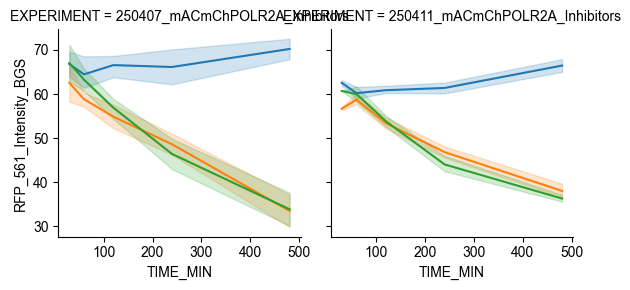

In [22]:
g = sns.FacetGrid(IntensitiesByWell.query('CELL == "HCT116 mChPOLR2A Clone 2"'), col = 'EXPERIMENT')

g.map_dataframe(sns.lineplot,
                x = 'TIME_MIN',
                y = 'RFP_561_Intensity_BGS',
                hue = 'DRUG_2')

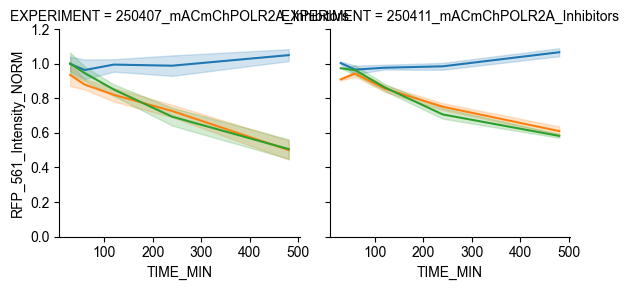

In [23]:
g = sns.FacetGrid(IntensitiesByWell.query('CELL == "HCT116 mChPOLR2A Clone 2"'), 
                  col = 'EXPERIMENT',
                 ylim = (0,1.2))

g.map_dataframe(sns.lineplot,
                x = 'TIME_MIN',
                y = 'RFP_561_Intensity_NORM',
                hue = 'DRUG_2')



(0.0, 1.2)

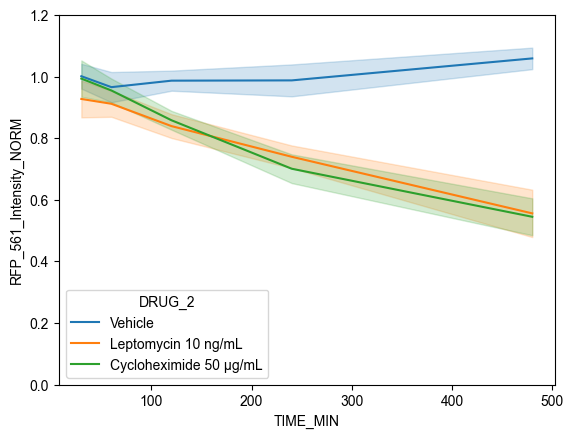

In [24]:
sns.lineplot(IntensitiesByWell.query('CELL == "HCT116 mChPOLR2A Clone 2"'),
             x = 'TIME_MIN',
             y = 'RFP_561_Intensity_NORM',
             hue = 'DRUG_2',
            errorbar = 'sd')
plt.ylim(0,1.2)

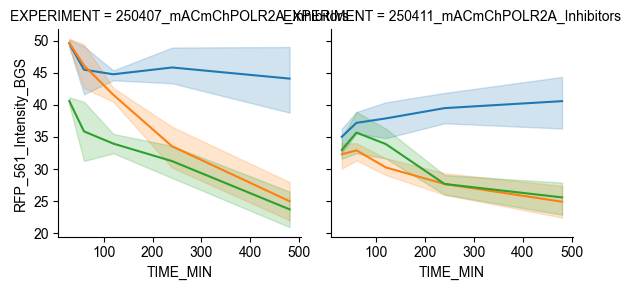

In [25]:
g = sns.FacetGrid(IntensitiesByWell
                  .query('CELL == "HCT116 OsTIRF74G mAC/mCh-POLR2A Clone 1" & DRUG_1 == "Vehicle"'), 
                  col = 'EXPERIMENT')

g.map_dataframe(sns.lineplot,
                x = 'TIME_MIN',
                y = 'RFP_561_Intensity_BGS',
                hue = 'DRUG_2')

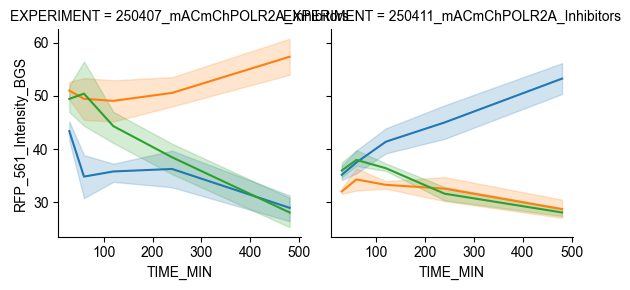

In [26]:
g = sns.FacetGrid(IntensitiesByWell
                  .query('CELL == "HCT116 OsTIRF74G mAC/mCh-POLR2A Clone 1" & DRUG_1 != "Vehicle"'), 
                  col = 'EXPERIMENT')

g.map_dataframe(sns.lineplot,
                x = 'TIME_MIN',
                y = 'RFP_561_Intensity_BGS',
                hue = 'DRUG_2')

(0.0, 1.0)

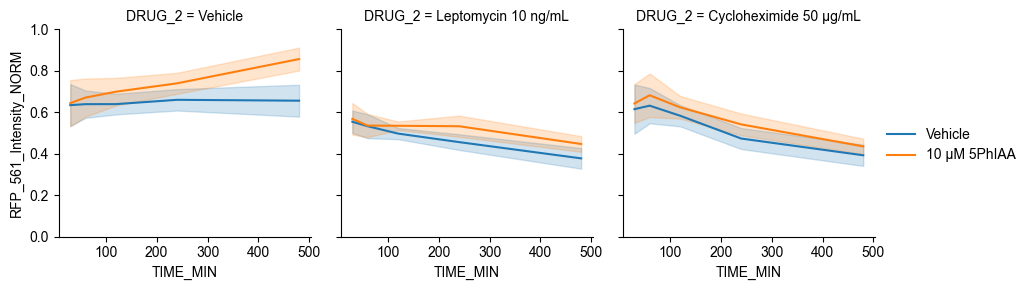

In [27]:
g = sns.FacetGrid(IntensitiesByWell
                  .query('CELL == "HCT116 OsTIRF74G mAC/mCh-POLR2A Clone 1"'), 
                  col = 'DRUG_2')

g.map_dataframe(sns.lineplot,
                x = 'TIME_MIN',
                y = 'RFP_561_Intensity_NORM',
                hue = 'DRUG_1', hue_order = ['Vehicle', '10 µM 5PhIAA'],
               errorbar = 'sd')

g.add_legend()

plt.ylim(0,1)

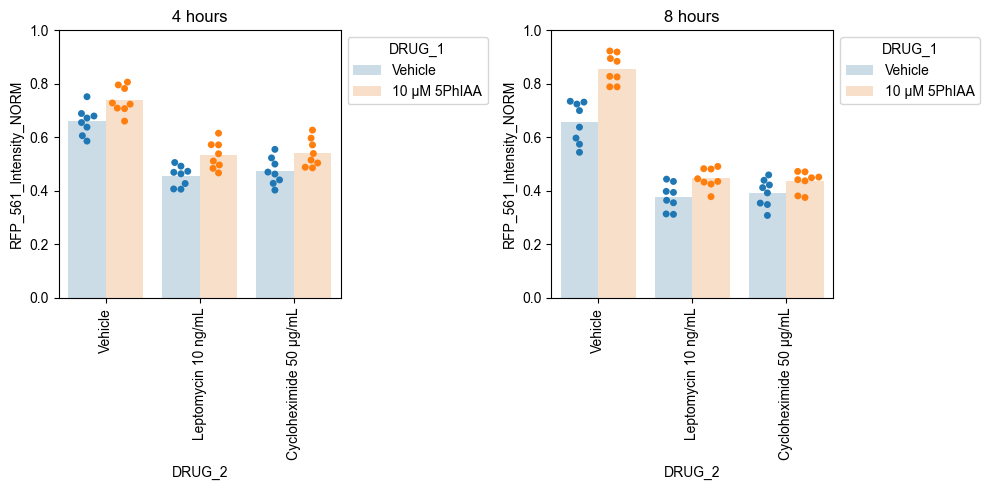

In [28]:
f, a = plt.subplots(figsize = (10,5), ncols = 2)

sns.swarmplot(IntensitiesByWell
              .query('CELL == "HCT116 OsTIRF74G mAC/mCh-POLR2A Clone 1" & TIME_MIN == 240'),
              x = 'DRUG_2',
              y = 'RFP_561_Intensity_NORM',
              hue = 'DRUG_1', dodge = True,
             legend = False,
             ax = a[0])

h = sns.barplot(IntensitiesByWell.query('CELL == "HCT116 OsTIRF74G mAC/mCh-POLR2A Clone 1" & TIME_MIN == 240'),
              x = 'DRUG_2',
              y = 'RFP_561_Intensity_NORM',
              hue = 'DRUG_1', dodge = True,
            errorbar = None,
           alpha = 0.25,
             ax = a[0])

sns.swarmplot(IntensitiesByWell
              .query('CELL == "HCT116 OsTIRF74G mAC/mCh-POLR2A Clone 1" & TIME_MIN == 480'),
              x = 'DRUG_2',
              y = 'RFP_561_Intensity_NORM',
              hue = 'DRUG_1', dodge = True,
             legend = False,
             ax = a[1])

i = sns.barplot(IntensitiesByWell.query('CELL == "HCT116 OsTIRF74G mAC/mCh-POLR2A Clone 1" & TIME_MIN == 480'),
              x = 'DRUG_2',
              y = 'RFP_561_Intensity_NORM',
              hue = 'DRUG_1', dodge = True,
            errorbar = None,
           alpha = 0.25,
             ax = a[1])


sns.move_legend(h, 'upper left', bbox_to_anchor = (1,1))
sns.move_legend(i, 'upper left', bbox_to_anchor = (1,1))

a[0].set_ylim(0,1)
a[1].set_ylim(0,1)

a[0].tick_params(axis='x', rotation=90)
a[1].tick_params(axis='x', rotation=90)

a[0].set_title('4 hours')
a[1].set_title('8 hours')


plt.tight_layout()

### plotting subtracted values to show residual auxin effect over time

In [29]:
IntensitiesByWellmACmCh = IntensitiesByWell.query('CELL == "HCT116 OsTIRF74G mAC/mCh-POLR2A Clone 1"')

In [30]:
IntensitiesByWellmACmCh = IntensitiesByWellmACmCh[['EXPERIMENT','DRUG_1','DRUG_2','TIME_MIN','RFP_561_Intensity_NORM']]

In [31]:
IntensitiesByWellmACmCh = IntensitiesByWellmACmCh.groupby(['EXPERIMENT','DRUG_1','DRUG_2','TIME_MIN']).mean().reset_index()

In [32]:
fs = []

for e in IntensitiesByWellmACmCh.EXPERIMENT.unique():
    e_frame = IntensitiesByWellmACmCh[IntensitiesByWellmACmCh.EXPERIMENT == e]

    for d2 in IntensitiesByWellmACmCh.DRUG_2.unique():
        d_frame = e_frame[e_frame.DRUG_2 == d2]

        t = d_frame[d_frame.DRUG_1 == 'Vehicle'].TIME_MIN.tolist()
        veh = d_frame[d_frame.DRUG_1 == 'Vehicle'].RFP_561_Intensity_NORM.tolist()
        aux = d_frame[d_frame.DRUG_1 == '10 µM 5PhIAA'].RFP_561_Intensity_NORM.tolist()

        aux_flat = np.subtract(aux,veh)

        f = pd.DataFrame({
            'EXPERIMENT' : np.tile(e,len(veh)),
            'DRUG_2' : np.tile(d2,len(veh)),
            'TIME_MIN' : t,
            'RFP_INT_NORM_VEHICLE' : veh,
            'RFP_INT_NORM_5PHIAA' : aux,
            'RFP_INT_NORM_SUBTRACTED' : aux_flat,
        })

        fs.append(f)

DF = pd.concat(fs)

(0.0, 1.0)

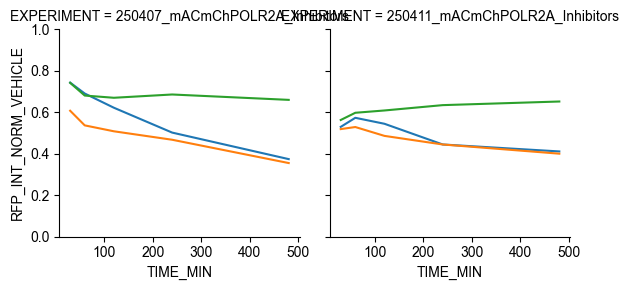

In [33]:
g = sns.FacetGrid(DF, col = 'EXPERIMENT')

g.map_dataframe(sns.lineplot,
                x = 'TIME_MIN',
                y = 'RFP_INT_NORM_VEHICLE',
                hue = 'DRUG_2')

plt.ylim(0,1)

(0.0, 1.0)

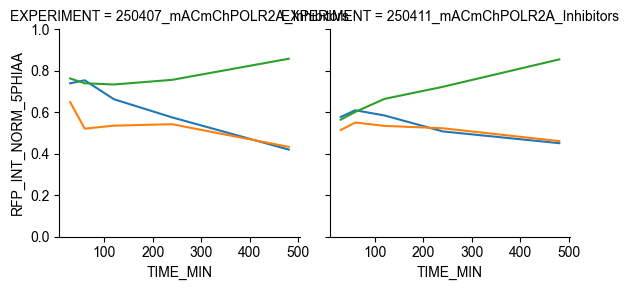

In [34]:
g = sns.FacetGrid(DF, col = 'EXPERIMENT')

g.map_dataframe(sns.lineplot,
                x = 'TIME_MIN',
                y = 'RFP_INT_NORM_5PHIAA',
                hue = 'DRUG_2')

plt.ylim(0,1)

(-0.1, 0.4)

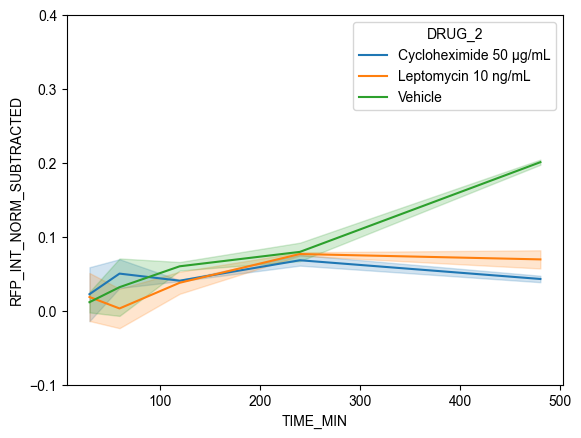

In [35]:
sns.lineplot(DF,
             x = 'TIME_MIN',
             y = 'RFP_INT_NORM_SUBTRACTED',
             hue = 'DRUG_2',
            errorbar = 'sd')

plt.ylim(-0.1,0.4)

### estimating POLR2A halflife using degradation

In [36]:
Decays = IntensitiesByWell.query('CELL == "HCT116 mChPOLR2A Clone 2" & DRUG_2 != "Vehicle"')

In [37]:
Decays = Decays.query('TIME_MIN > 30')

<Axes: xlabel='TIME_MIN', ylabel='RFP_561_Intensity_NORM'>

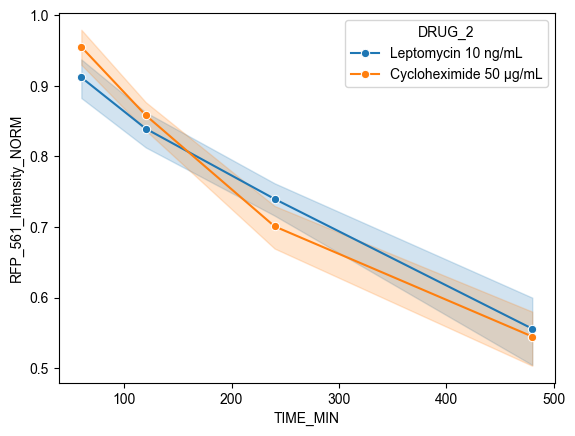

In [38]:
sns.lineplot(Decays,
             x = 'TIME_MIN',
             y = 'RFP_561_Intensity_NORM',
             hue = 'DRUG_2',
             marker = 'o')


In [39]:
Decays['RFP_log'] = np.log(Decays['RFP_561_Intensity_NORM'])

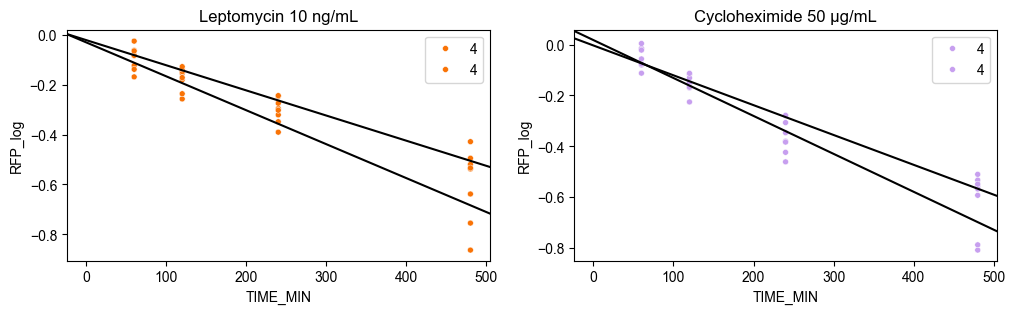

In [40]:
f, a = plt.subplots(ncols = 2, figsize = (12,3))

ls = []

for enu,d in enumerate(Decays.DRUG_2.unique()):

        d_frame = Decays[Decays.DRUG_2 == d]

        for e in Decays.EXPERIMENT.unique():
            
            e_frame = d_frame[d_frame.EXPERIMENT == e]

            if d == "Leptomycin 10 ng/mL":
                point_colour = "xkcd:orange"
            elif d == "Cycloheximide 50 µg/mL":
                point_colour = "xkcd:lavender"
    
            sns.scatterplot(e_frame, 
                            x = 'TIME_MIN',
                            y = 'RFP_log', ax = a[enu], size = 4, color = point_colour)
    
    
            x_vals = e_frame.TIME_MIN.tolist()
            y_vals = e_frame.RFP_log.tolist()
    
            l = scipy.stats.linregress(x = x_vals, y = y_vals)
            keys = ["experiment", "drug", "slope", "intercept", "rvalue", "pvalue", "stderr", "intercept_stderr"]
            vals = [[e],[d],[l.slope], [l.intercept], [l.rvalue], [l.pvalue], [l.stderr], [l.intercept_stderr]]
    
            f = pd.DataFrame( dict(zip(keys,vals)) )
            ls.append(f)
    
            a[enu].axline( (0, l.intercept) , slope=l.slope, color='black')
    
            #a[enu].set_ylim(3,4.5)
    
            a[enu].set_title(d)
    
RegressionResults = pd.concat(ls)

In [41]:
RegressionResults['slope_perhour'] = RegressionResults['slope']*-1*60

In [42]:
RegressionResults['halflife_hours'] = np.log(2) / RegressionResults['slope_perhour']

(0.0, 0.1)

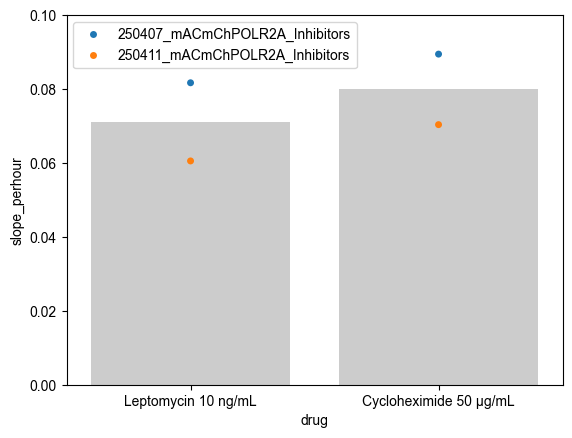

In [43]:
sns.swarmplot(RegressionResults, x = 'drug', hue = 'experiment', y = 'slope_perhour')
sns.barplot(RegressionResults, x = 'drug', y = 'slope_perhour', alpha = 0.2, errorbar = None, color = 'black')

plt.ylim(0,0.1)


<Axes: xlabel='drug', ylabel='halflife_hours'>

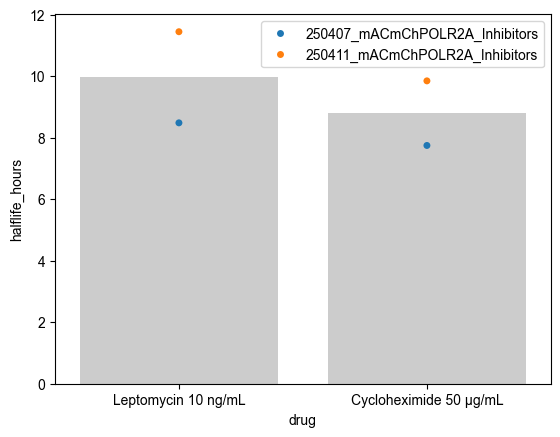

In [44]:
sns.swarmplot(RegressionResults, x = 'drug', hue = 'experiment', y = 'halflife_hours')
sns.barplot(RegressionResults, x = 'drug', y = 'halflife_hours', alpha = 0.2, errorbar = None, color = 'black')


## making some plots for a talk

(0.0, 1.0)

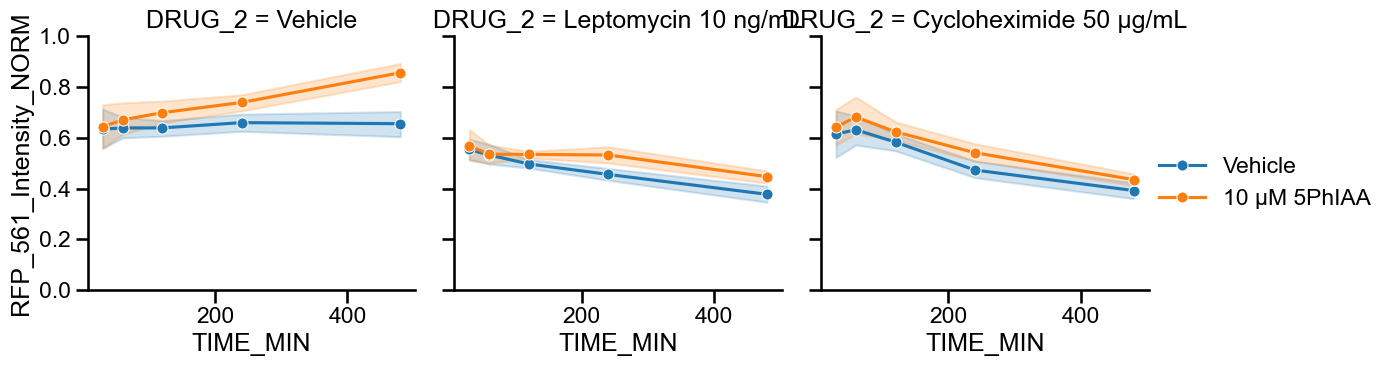

In [45]:
sns.set_context('talk')

g = sns.FacetGrid(IntensitiesByWell
                  .query('CELL == "HCT116 OsTIRF74G mAC/mCh-POLR2A Clone 1"'), 
                  col = 'DRUG_2',
                 height = 4)

g.map_dataframe(sns.lineplot,
                x = 'TIME_MIN',
                y = 'RFP_561_Intensity_NORM',
                hue = 'DRUG_1', hue_order = ['Vehicle', '10 µM 5PhIAA'],
               marker = 'o', markersize = 8)

g.add_legend()

plt.ylim(0,1)

In [46]:
mACmCh_Intensities_ForPlot = IntensitiesByWell.query('CELL == "HCT116 OsTIRF74G mAC/mCh-POLR2A Clone 1"')


In [47]:
mACmCh_Intensities_ForPlot['TIME_HOUR'] = mACmCh_Intensities_ForPlot['TIME_MIN']/60

/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_32036/862372751.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mACmCh_Intensities_ForPlot['TIME_HOUR'] = mACmCh_Intensities_ForPlot['TIME_MIN']/60


In [48]:
IntensitiesByWell.DRUG_1.unique()

array(['Vehicle', '10 µM 5PhIAA'], dtype=object)

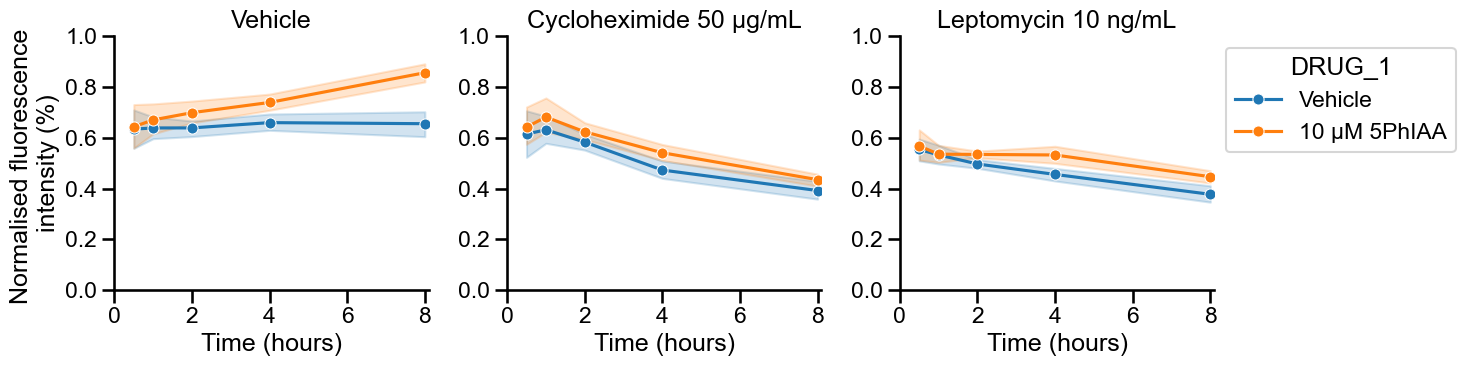

In [49]:
f, a = plt.subplots(ncols = 3, figsize = (15,4))

h = sns.lineplot(mACmCh_Intensities_ForPlot.query('DRUG_2 == "Vehicle"'),
             x = 'TIME_HOUR',
             y = 'RFP_561_Intensity_NORM',
             hue = 'DRUG_1', hue_order = ['Vehicle', '10 µM 5PhIAA'],
                 marker = 'o', markersize = 8,
             ax = a[0],
             legend = False)

sns.lineplot(mACmCh_Intensities_ForPlot.query('DRUG_2 == "Cycloheximide 50 µg/mL"'),
             x = 'TIME_HOUR',
             y = 'RFP_561_Intensity_NORM',
             hue = 'DRUG_1', hue_order = ['Vehicle', '10 µM 5PhIAA'],
                 marker = 'o', markersize = 8,
             ax = a[1],
             legend = False)

p = sns.lineplot(mACmCh_Intensities_ForPlot.query('DRUG_2 == "Leptomycin 10 ng/mL"'),
             x = 'TIME_HOUR',
             y = 'RFP_561_Intensity_NORM',
             hue = 'DRUG_1', hue_order = ['Vehicle', '10 µM 5PhIAA'],
                 marker = 'o', markersize = 8,
             ax = a[2])

sns.move_legend(p, 'upper left', bbox_to_anchor = (1,1))
sns.despine()


titles = ['Vehicle', 'Cycloheximide 50 µg/mL', 'Leptomycin 10 ng/mL']

a[0].set_ylabel('Normalised fluorescence \nintensity (%)')
a[1].set_ylabel('')
a[2].set_ylabel('')

for i in range(3):
    a[i].set_ylim(0,1)
    a[i].set_xlim(0,8.1)
    a[i].set_xticks(np.linspace(0,8,5))
    a[i].set_xlabel('Time (hours)')
    a[i].set_title(titles[i])

plt.tight_layout()

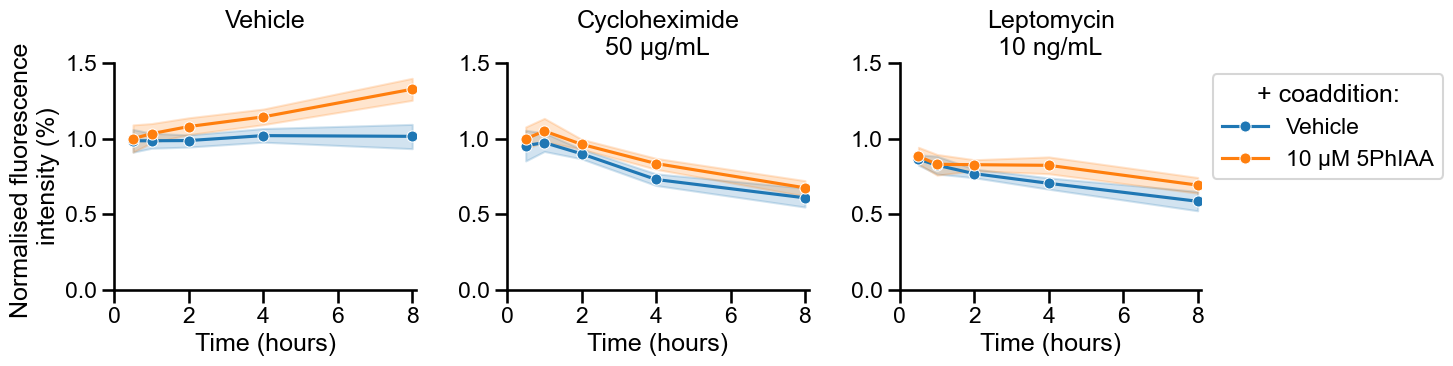

In [50]:
f, a = plt.subplots(ncols = 3, figsize = (15,4))

h = sns.lineplot(mACmCh_Intensities_ForPlot.query('DRUG_2 == "Vehicle"'),
             x = 'TIME_HOUR',
             y = 'RFP_561_Intensity_NORM2',
             hue = 'DRUG_1', hue_order = ['Vehicle', '10 µM 5PhIAA'],
                 marker = 'o', markersize = 8,
             ax = a[0],
             legend = False)

sns.lineplot(mACmCh_Intensities_ForPlot.query('DRUG_2 == "Cycloheximide 50 µg/mL"'),
             x = 'TIME_HOUR',
             y = 'RFP_561_Intensity_NORM2',
             hue = 'DRUG_1', hue_order = ['Vehicle', '10 µM 5PhIAA'],
                 marker = 'o', markersize = 8,
             ax = a[1],
             legend = False)

p = sns.lineplot(mACmCh_Intensities_ForPlot.query('DRUG_2 == "Leptomycin 10 ng/mL"'),
             x = 'TIME_HOUR',
             y = 'RFP_561_Intensity_NORM2',
             hue = 'DRUG_1', hue_order = ['Vehicle', '10 µM 5PhIAA'],
                 marker = 'o', markersize = 8,
             ax = a[2])

a[2].legend(title = '+ coaddition:')

sns.move_legend(p, 'upper left', bbox_to_anchor = (1,1))
sns.despine()


titles = ['Vehicle\n ', 'Cycloheximide\n50 µg/mL', 'Leptomycin\n10 ng/mL']

a[0].set_ylabel('Normalised fluorescence \nintensity (%)')
a[1].set_ylabel('')
a[2].set_ylabel('')


for i in range(3):
    a[i].set_ylim(0,1.5)
    a[i].set_xlim(0,8.1)
    a[i].set_xticks(np.linspace(0,8,5))
    a[i].set_xlabel('Time (hours)')
    a[i].set_title(titles[i])

plt.tight_layout()

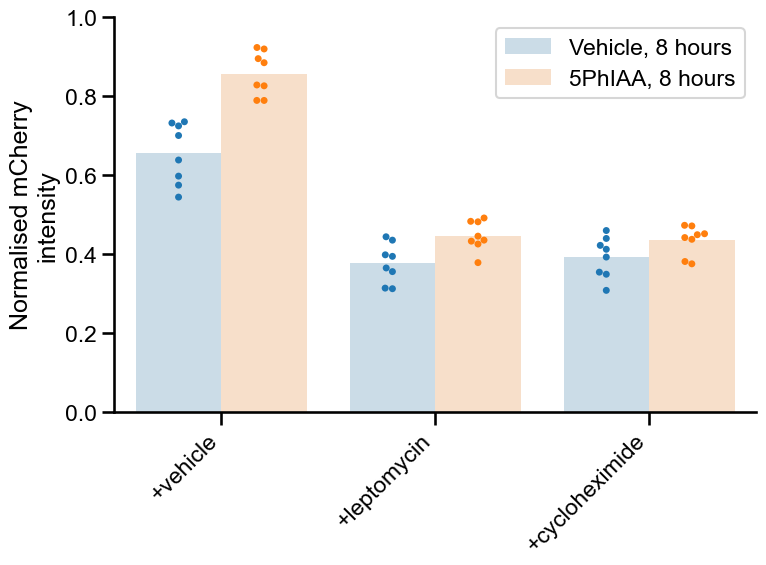

In [51]:
f, a = plt.subplots(figsize = (8,6))

sns.set_context('talk')

sns.swarmplot(IntensitiesByWell
              .query('CELL == "HCT116 OsTIRF74G mAC/mCh-POLR2A Clone 1" & TIME_MIN == 480'),
              x = 'DRUG_2',
              y = 'RFP_561_Intensity_NORM',
              hue = 'DRUG_1', dodge = True,
             legend = False,
             ax = a)

i = sns.barplot(IntensitiesByWell.query('CELL == "HCT116 OsTIRF74G mAC/mCh-POLR2A Clone 1" & TIME_MIN == 480'),
              x = 'DRUG_2',
              y = 'RFP_561_Intensity_NORM',
              hue = 'DRUG_1', dodge = True,
            errorbar = None,
           alpha = 0.25,
             ax = a)



sns.move_legend(i, 'upper left', bbox_to_anchor = (1,1))

a.set_ylim(0,1)

a.set_ylabel('Normalised mCherry\nintensity')

a.tick_params(axis='x', rotation=90)

a.set_xticks(ticks = [0,1,2], labels = ['+vehicle', '+leptomycin', '+cycloheximide'], rotation = 45, ha = 'right')
a.set_xlabel('')

legend_handles, _= a.get_legend_handles_labels()
a.legend(legend_handles, ['Vehicle, 8 hours', '5PhIAA, 8 hours'], 
          bbox_to_anchor=(1,1), 
          title='')

sns.despine()

plt.tight_layout()

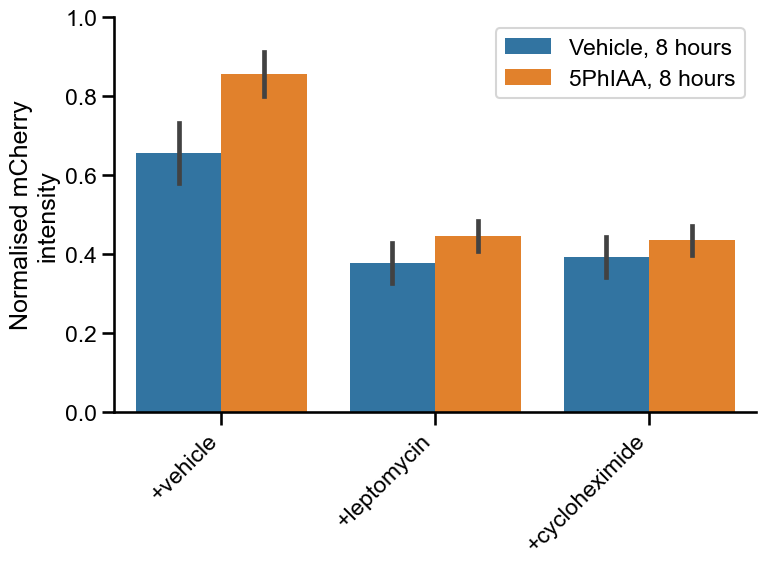

In [52]:
f, a = plt.subplots(figsize = (8,6))

sns.set_context('talk')

i = sns.barplot(IntensitiesByWell.query('CELL == "HCT116 OsTIRF74G mAC/mCh-POLR2A Clone 1" & TIME_MIN == 480'),
              x = 'DRUG_2',
              y = 'RFP_561_Intensity_NORM',
              hue = 'DRUG_1', dodge = True,
            errorbar = 'sd',
             ax = a)



sns.move_legend(i, 'upper left', bbox_to_anchor = (1,1))

a.set_ylim(0,1)

a.set_ylabel('Normalised mCherry\nintensity')

a.tick_params(axis='x', rotation=90)

a.set_xticks(ticks = [0,1,2], labels = ['+vehicle', '+leptomycin', '+cycloheximide'], rotation = 45, ha = 'right')
a.set_xlabel('')

legend_handles, _= a.get_legend_handles_labels()
a.legend(legend_handles, ['Vehicle, 8 hours', '5PhIAA, 8 hours'], 
          bbox_to_anchor=(1,1), 
          title='')

sns.despine()

plt.tight_layout()

## plots for manuscript

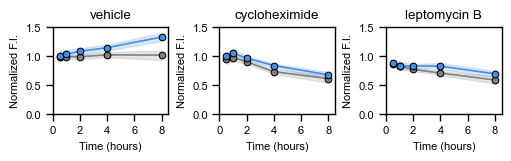

In [53]:
sns.set_context('paper')

f, a = plt.subplots(ncols = 3, figsize = (5,1.5), layout = 'constrained')

pal = sns.color_palette(['grey', 'xkcd:dark sky blue'])

h = sns.lineplot(mACmCh_Intensities_ForPlot.query('DRUG_2 == "Vehicle"'),
             x = 'TIME_HOUR',
             y = 'RFP_561_Intensity_NORM2',
             hue = 'DRUG_1', hue_order = ['Vehicle', '10 µM 5PhIAA'], palette = pal,
                 marker = 'o', markeredgecolor = 'black',
             ax = a[0],
             legend = False)

sns.lineplot(mACmCh_Intensities_ForPlot.query('DRUG_2 == "Cycloheximide 50 µg/mL"'),
             x = 'TIME_HOUR',
             y = 'RFP_561_Intensity_NORM2',
             hue = 'DRUG_1', hue_order = ['Vehicle', '10 µM 5PhIAA'], palette = pal,
                 marker = 'o', markeredgecolor = 'black',
             ax = a[1],
             legend = False)

p = sns.lineplot(mACmCh_Intensities_ForPlot.query('DRUG_2 == "Leptomycin 10 ng/mL"'),
             x = 'TIME_HOUR',
             y = 'RFP_561_Intensity_NORM2',
             hue = 'DRUG_1', hue_order = ['Vehicle', '10 µM 5PhIAA'], palette = pal,
                 marker = 'o', markeredgecolor = 'black',
             ax = a[2],
                 legend = False)

a[0].set_ylabel('(normalized F.I.)')
a[1].set_ylabel('')
a[2].set_ylabel('')

a[0].set_title('vehicle')
a[1].set_title('cycloheximide')
a[2].set_title('leptomycin B')

for i in range(3):
    a[i].set_ylim(0,1.5)
    a[i].set_yticks([0,0.5,1,1.5])
    a[i].set_xlim(0,8.5)
    a[i].set_xticks(np.linspace(0,8,5))
    a[i].set_xlabel('Time (hours)', fontsize = 8)
    a[i].set_ylabel('Normalized F.I.', fontsize = 8)
    a[i].tick_params(axis = 'both', labelsize = 8)


plt.savefig('macmch_5Ph_CHXLMB_baseline.svg')

### save normalized data to csv

In [54]:
mACmCh_Intensities_ForPlot.columns.tolist()

['EXPERIMENT',
 'WELL',
 'RFP_561_Intensity',
 'GFP_488_Intensity',
 'DAPI_Intensity',
 'NucleusArea',
 'CELL',
 'DRUG_1',
 'DRUG_TIME_MINUTES_1',
 'DRUG_2',
 'DRUG_TIME_MINUTES_2',
 'TotalNumberCells',
 'RFP_561_Intensity_BGS',
 'RFP_561_Intensity_NORM',
 'RFP_561_Intensity_NORM2',
 'TIME_MIN',
 'TIME_HOUR']

In [57]:
mACmChPOLR2A_Inhibitors_well_summary_rfp_normalised = mACmCh_Intensities_ForPlot[['EXPERIMENT',
 'WELL','CELL',
 'DRUG_1',
 'DRUG_TIME_MINUTES_1',
 'DRUG_2',
 'DRUG_TIME_MINUTES_2',
 'TIME_HOUR',
 'TotalNumberCells',
 'RFP_561_Intensity',
 'RFP_561_Intensity_BGS',
 'RFP_561_Intensity_NORM2']]

mACmChPOLR2A_Inhibitors_well_summary_rfp_normalised.to_csv('mACmChPOLR2A_Inhibitors_well_summary_rfp_normalised.csv')

### adjusted to relative biallelic mCherryPOLR2A fluorescence

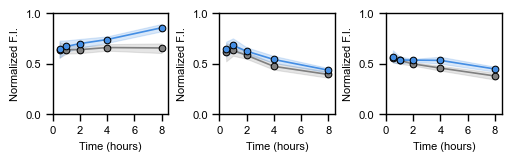

In [112]:
sns.set_context('paper')

f, a = plt.subplots(ncols = 3, figsize = (5,1.5), layout = 'constrained')

pal = sns.color_palette(['grey', 'xkcd:dark sky blue'])

h = sns.lineplot(mACmCh_Intensities_ForPlot.query('DRUG_2 == "Vehicle"'),
             x = 'TIME_HOUR',
             y = 'RFP_561_Intensity_NORM',
             hue = 'DRUG_1', hue_order = ['Vehicle', '10 µM 5PhIAA'], palette = pal,
                 marker = 'o', markeredgecolor = 'black',
             ax = a[0],
             legend = False)

sns.lineplot(mACmCh_Intensities_ForPlot.query('DRUG_2 == "Cycloheximide 50 µg/mL"'),
             x = 'TIME_HOUR',
             y = 'RFP_561_Intensity_NORM',
             hue = 'DRUG_1', hue_order = ['Vehicle', '10 µM 5PhIAA'], palette = pal,
                 marker = 'o', markeredgecolor = 'black',
             ax = a[1],
             legend = False)

p = sns.lineplot(mACmCh_Intensities_ForPlot.query('DRUG_2 == "Leptomycin 10 ng/mL"'),
             x = 'TIME_HOUR',
             y = 'RFP_561_Intensity_NORM',
             hue = 'DRUG_1', hue_order = ['Vehicle', '10 µM 5PhIAA'], palette = pal,
                 marker = 'o', markeredgecolor = 'black',
             ax = a[2],
                 legend = False)

a[0].set_ylabel('(normalized F.I.)')
a[1].set_ylabel('')
a[2].set_ylabel('')


for i in range(3):
    a[i].set_ylim(0,1)
    a[i].set_yticks([0,0.5,1])
    a[i].set_xlim(0,8.5)
    a[i].set_xticks(np.linspace(0,8,5))
    a[i].set_xlabel('Time (hours)', fontsize = 8)
    a[i].set_ylabel('Normalized F.I.', fontsize = 8)
    a[i].tick_params(axis = 'both', labelsize = 8)


plt.savefig('macmch_5Ph_CHXLMB_baselinep6.svg')